#실행7_1_1

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats

In [2]:
#카이제곱 독립성 검정
#data : 빈도표
data_chi = pd. DataFrame ({
 'income': ['high', 'high', 'low', 'low'],
 'high': ['yes', 'no', 'yes', 'no'],
 'f': [54,45,63,65] })
print(data_chi)

  income high   f
0   high  yes  54
1   high   no  45
2    low  yes  63
3    low   no  65


high     no  yes  All
income               
high     45   54   99
low      65   63  128
All     110  117  227
high     no  yes  All
income               
high     45   54   99
low      65   63  128
All     110  117  227


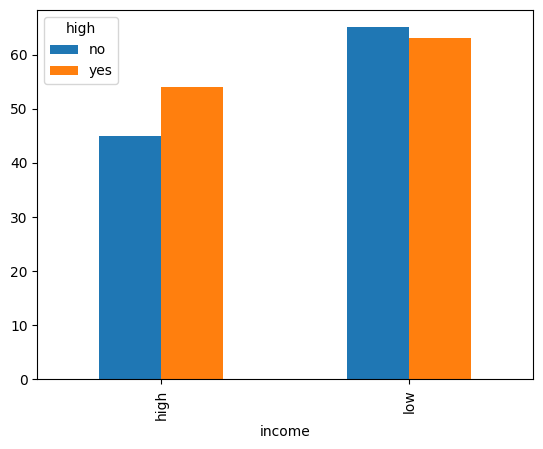

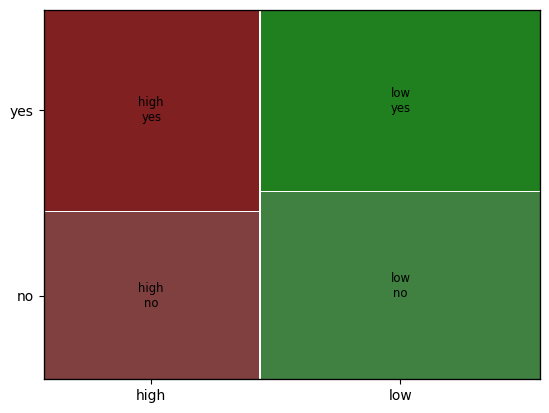

In [15]:
#crosstab 이원분할표 (교차표)
data_chi_ct1 = pd.crosstab(
 index=data_chi['income'],
 columns=data_chi['high'],
 values=data_chi['f'],
 aggfunc='sum',
 margins=True)
print(data_chi_ct1)

#pivot_table 교차표
data_chi_ct2 = pd.pivot_table(data=data_chi,
 index='income',
 columns='high',
 values='f',
 aggfunc='sum', #default가 sum이라 생략해도 됨
 margins=True)
print(data_chi_ct2)


#교차표 막대그래프 그리기
data_chi_plot = pd.pivot_table(data=data_chi,
 index='income',
 columns='high',
 values='f')
data_chi_plot.plot(kind='bar', stacked=False)

#모자이크 그림
from statsmodels.graphics.mosaicplot import mosaic
mosaic(data_chi_plot.stack()); plt.show()  #data_chi_plot.stack():모자이크 함수는 stack 형식으로 넣어야 함, data_chi는 모양이 같지만 가중치로 인식하지 못하고 있기 때문에 쓰면 X
#stack()으로 Series(멀티인덱스)로 변환해서 전달

In [4]:
#카이제곱 독립성 검정
#가설) H0: 두 변수는 서로 독립이다 / H1: 두 변수는 서로 연관이 있다
chi2, p_value, df, expected = stats.chi2_contingency(data_chi_plot, correction=True)
  #correction은 연속성보정 여부 선택, 2*2교차표에서만 연속성 보정, default는 True

#결과 출력
print(f"chi2: {chi2:.3f}, df:{df}")
print(f"P-value: {p_value:.4f}")
print("기대도수:")
print(expected.round(2))
#신뢰구간 없음

#해석
if p_value < 0.05:
 print("귀무가설을 기각합니다. 두 변수는 서로 연관이 있습니다.")
else:
 print("귀무가설을 채택합니다. 두 변수는 서로 독립입니다.")

# df = (2-1)*(2-1)

chi2: 0.439, df:1
P-value: 0.5077
기대도수:
[[47.97 51.03]
 [62.03 65.97]]
귀무가설을 채택합니다. 두 변수는 서로 독립입니다.


# 실행7_1_2

In [5]:
#data : raw data 형식 (students 데이터)
from google.colab import drive
#구글 드라이브 마운트(연결)
drive.mount('/content/drive')
#드라이브에 저장된 파일 경로 지정
file_path = '/content/drive/MyDrive/Colab_ex_data/students.csv'
#데이터프레임 만들기
df_students = pd.read_csv(file_path)
df_students

Mounted at /content/drive


,id,grade,major,math,english,science
0,1,grade1,A,50,98,50
1,2,grade1,A,60,97,60
2,3,grade1,A,45,86,78
3,4,grade1,A,30,98,58
4,5,grade1,A,25,80,65
5,6,grade1,A,51,97,55
6,7,grade1,A,61,96,65
7,8,grade1,A,46,85,83
8,9,grade1,B,31,97,63
9,10,grade1,B,26,79,70


math_g   A   B   C  All
grade                  
grade1   2   4   9   15
grade2   6   3  10   19
grade3   0   4   6   10
grade4   4   2   0    6
All     12  13  25   50


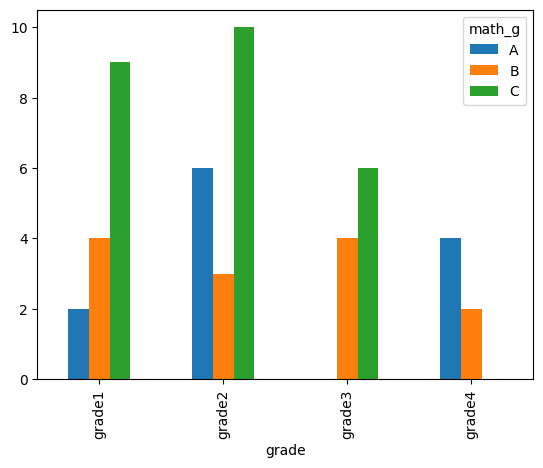

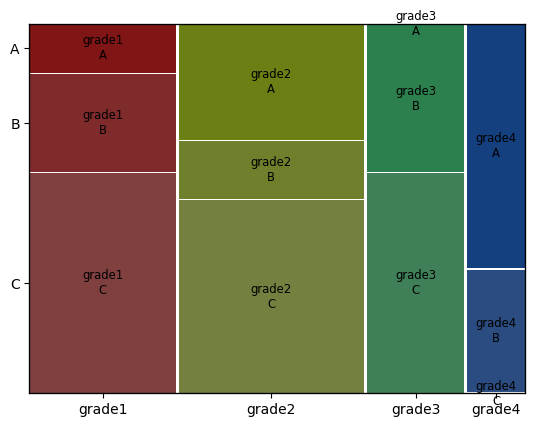

In [6]:
#수학점수 연속형 변수를 범주형으로 바꾸기
df_students['math_g'] = np.select(
 [df_students['math']>= 80, df_students['math']>= 60, df_students['math']>= 0],
 ['A', 'B', 'C'], default='etc')

#교차표
students_ct = pd.crosstab(df_students['grade'], df_students['math_g'], margins=True)
print(students_ct)

#두 개 범주형 변수에 대한 막대그래프
students_plot = pd.crosstab(df_students['grade'], df_students['math_g'])
students_plot.plot(kind='bar', stacked=False); plt.show()

#모자이크 그림
from statsmodels.graphics.mosaicplot import mosaic
mosaic(df_students, ['grade', 'math_g']); plt.show()  #mosaic(df_students, ['grade', 'math_g']): raw 데이터를 가지고 있을 때는 이 코드 씀

In [7]:
#카이제곱 독립성 검정
chi2, p_value, df, expected = stats.chi2_contingency(students_plot, correction=False)  #2*2가 아니니까 correction=False, 2*2가 아니니까 빼도 알아서 correcrion=False됨

#결과 출력
print(f"chi2: {chi2:.3f}, df:{df}")
print(f"P-value: {p_value:.4f}")
print("기대도수:")
print(expected.round(2))

#해석
if p_value < 0.05:
 print("귀무가설을 기각합니다. 두 변수는 서로 연관이 있습니다.")
else:
 print("귀무가설을 채택합니다. 두 변수는 서로 독립입니다.")

 #기대도수가 5 이하인 셀들이 많으면 카이제곱 검정 말고 다른 비모수적인 검정을 행해야 한다.5보다 커야 인정될 만함

chi2: 13.286, df:6
P-value: 0.0387
기대도수:
[[3.6  3.9  7.5 ]
 [4.56 4.94 9.5 ]
 [2.4  2.6  5.  ]
 [1.44 1.56 3.  ]]
귀무가설을 기각합니다. 두 변수는 서로 연관이 있습니다.


#실행7_2_1

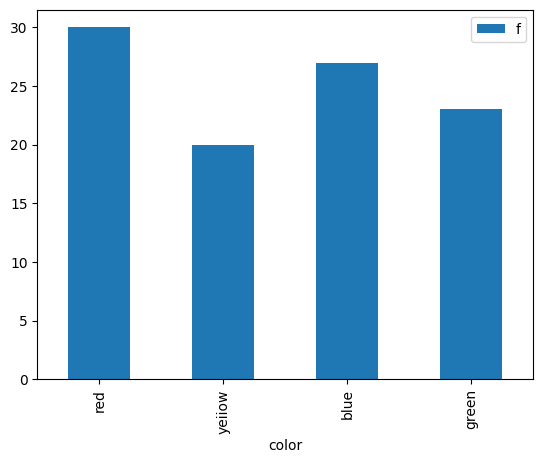

[25. 25. 25. 25.]


In [8]:
#적합도 검정
#가설) H0:각 범주의 확률이 귀무가설의 주어진 확률과 같다 / H1:적어도 하나의 범주는 주어진 확률에 적합하지 않는다

#data
data_gof = pd. DataFrame ({
 'color': ['red', 'yeiiow', 'blue', 'green'],
 'f': [30,20,27,23] })

#막대그래프
data_gof.plot(kind='bar', x='color', y='f'); plt.show();

#관측도수
obs = data_gof['f']   #또는 바로 obs = np.array([30,20,27,23]) 입력

#귀무가설 범주별 확률
p0 = np.array([0.25, 0.25, 0.25, 0.25])

#기대도수
exp = p0 * obs.sum()
print(exp)

In [9]:
#적합도검정
chi2, p_value = stats.chisquare(f_obs=obs, f_exp=exp)  #f_obs: 관측 도수, f_eps: 기대도수
df = len(obs) - 1   #범주의 개수 - 1

#결과 출력
print(f"chi2: {chi2:.3f}, df:{df}")
print(f"P-value: {p_value:.4f}")

#해석
if p_value < 0.05:
 print("귀무가설을 기각합니다. 각 색상별 알사탕수의 비율이 동일하지 않습니다.")
else:
 print("귀무가설을 채택합니다. 각 색상별 알사탕수의 비율이 동일합니다.")

chi2: 2.320, df:3
P-value: 0.5087
귀무가설을 채택합니다. 각 색상별 알사탕수의 비율이 동일합니다.


#실행7_2_2

grade
grade2    19
grade1    15
grade3    10
grade4     6
Name: count, dtype: int64


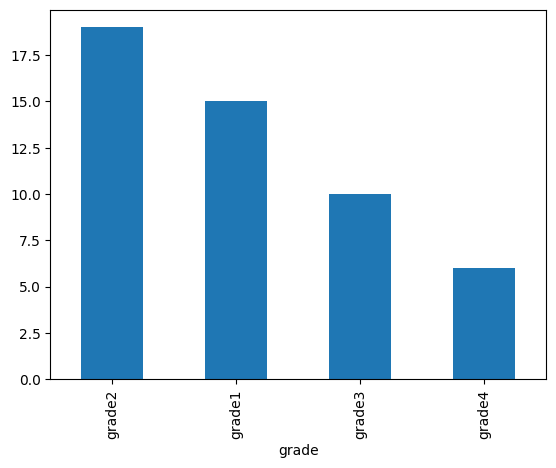

chi2: 7.760, df:3
P-value: 0.0512
귀무가설을 채택합니다. 학년 비율이 모두 동일합니다.


In [10]:
#data : raw data 형식 (students 데이터)
#가설) H0:학년 비율이 모두 동일하다 / H1:학년 비율이 모두 동일하지는 않다
#막대그래프
print(df_students['grade'].value_counts())
df_students['grade'].value_counts().plot(kind='bar'); plt.show();

#관측도수
obs = df_students['grade'].value_counts()

#귀무가설 범주별 확률
p0 = np.array([0.25, 0.25, 0.25, 0.25])  #합계가 반드시 1이어야 함

#기대도수
exp = p0 * obs.sum()

#적합도검정
chi2, p_value = stats.chisquare(f_obs=obs, f_exp=exp)
df = len(obs) - 1

#결과 출력
print(f"chi2: {chi2:.3f}, df:{df}")
print(f"P-value: {p_value:.4f}")

#해석
if p_value < 0.05:
 print("귀무가설을 기각합니다. 학년 비율이 모두 동일하지는 않습니다.")
else:
 print("귀무가설을 채택합니다. 학년 비율이 모두 동일합니다.")

유의수준 0.05보다는 크지만 유의수준 0.1에서는 H0을 기각할 수 있다.

#연습7_1_1

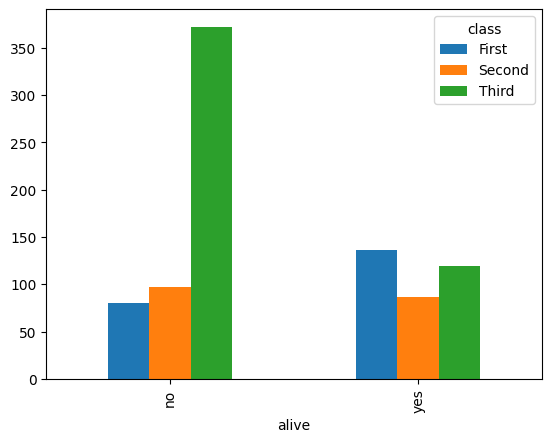

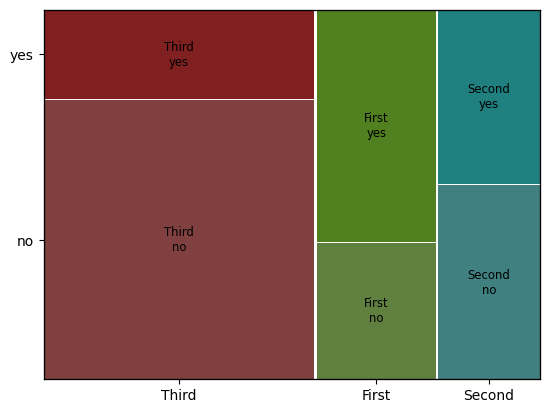

class    First    Second     Third       All
alive                                       
no     0.37037  0.527174  0.757637  0.616162
yes    0.62963  0.472826  0.242363  0.383838
chi2: 102.889, df:2
P-value: 0.0000
귀무가설을 기각합니다. 두 변수는 서로 연관이 있습니다.


In [11]:
df_titanic=sns.load_dataset('titanic')

#두 개 범주형 변수에 대한 막대그래프
titanic_plot = pd.crosstab(df_titanic['alive'], df_titanic['class'])
titanic_plot.plot(kind='bar', stacked=False); plt.show()

#모자이크 그림
from statsmodels.graphics.mosaicplot import mosaic
mosaic(df_titanic, ['class', 'alive']); plt.show()

#카이제곱 독립성 검정
#가설) H0: 두 변수는 서로 독립이다 / H1: 두 변수는 서로 연관이 있다
chi2, p_value, df, expected = stats.chi2_contingency(titanic_plot, correction=False)

#교차표 출력
print(pd.crosstab(df_titanic['alive'],df_titanic['class'], margins=True, normalize='columns'))

#결과 출력
print(f"chi2: {chi2:.3f}, df:{df}")
print(f"P-value: {p_value:.4f}")

#해석
if p_value < 0.05:
 print("귀무가설을 기각합니다. 두 변수는 서로 연관이 있습니다.")
else:
 print("귀무가설을 채택합니다. 두 변수는 서로 독립입니다.")

#연습7_1_2

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64


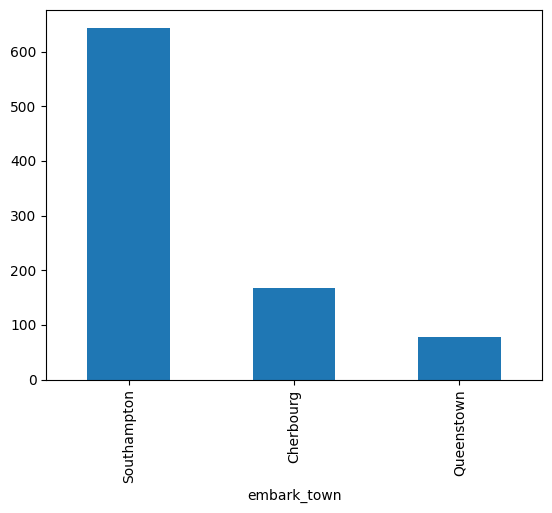

chi2: 625.811, df:2
P-value: 0.0000
귀무가설을 기각합니다. 학년 비율이 모두 동일하지는 않습니다.


In [12]:
#막대그래프
print(df_titanic['embark_town'].value_counts())
df_titanic['embark_town'].value_counts().plot(kind='bar'); plt.show();

#관측도수
obs = df_titanic['embark_town'].value_counts()

#귀무가설 범주별 확률
p0 = np.array([1/3,1/3,1/3])  #합계가 반드시 1이어야 함

#기대도수
exp = p0 * obs.sum()


#적합도검정
chi2, p_value = stats.chisquare(f_obs=obs, f_exp=exp)
df = len(obs) - 1

#결과 출력
print(f"chi2: {chi2:.3f}, df:{df}")
print(f"P-value: {p_value:.4f}")

#해석
if p_value < 0.05:
 print("귀무가설을 기각합니다. 학년 비율이 모두 동일하지는 않습니다.")
else:
 print("귀무가설을 채택합니다. 학년 비율이 모두 동일합니다.")